In [26]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input, Lambda,UpSampling2D, Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,BatchNormalization, Activation
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
import sys
import os
import numpy as np
import math
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

In [27]:
specific_directory = '/home/ppgi/Trabajo/predicting-flow-patterns/P_Masked'

path_train ='/home/ppgi/Trabajo/predicting-flow-patterns/P_Masked/train'
path_test ='/home/ppgi/Trabajo/predicting-flow-patterns/P_Masked/test'
path_val= '/home/ppgi/Trabajo/predicting-flow-patterns/P_Masked/valid'

nbatch = 10

def dataset_array(flow_path,geo_path):
    def load_array(flow,geo):
        x = np.load(flow)
        y = np.load(geo)
        return x,y

    x, y = tf.numpy_function(load_array, [flow_path, geo_path], [tf.float64, tf.float64])
    x.set_shape([x.shape[0],x.shape[1],x.shape[2]])
    y.set_shape([y.shape[0],y.shape[1],y.shape[2]])
    return x,y

def create_dataset(flow_path,geo_path,batch_size = nbatch):
    x_files = sorted(glob.glob(os.path.join(flow_path, "*.npy")))
    y_files = sorted(glob.glob(os.path.join(geo_path, "*.npy")))
    dataset = tf.data.Dataset.from_tensor_slices((x_files, y_files))
    dataset = dataset.map(dataset_array, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    return dataset

In [28]:
geo_path_train='/home/ppgi/Trabajo/predicting-flow-patterns/G_Masked/train'
p_path_train='/home/ppgi/Trabajo/predicting-flow-patterns/P_Masked/train'

geo_path_valid='/home/ppgi/Trabajo/predicting-flow-patterns/G_Masked/valid'
p_path_valid='/home/ppgi/Trabajo/predicting-flow-patterns/P_Masked/valid'

geo_path_test='/home/ppgi/Trabajo/predicting-flow-patterns/G_Masked/test'
p_path_test='/home/ppgi/Trabajo/predicting-flow-patterns/P_Masked/test'

train_ds =create_dataset(geo_path_train,p_path_train)
test_ds  =create_dataset(geo_path_test,p_path_test)
valid_ds =create_dataset(geo_path_valid,p_path_valid)

In [29]:
num_epochs    =50
patience      =5      # How long to wait after last time validation loss improved
LR            =0.001

# Model name
model_name    ="U-Net"
save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1

#number_of_filters = [64, 128, 256, 512, 1024]
number_of_filters = [32,64,128,256,512]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
#optimizer = RMSprop(learning_rate=LR)
optimizer = Adam(learning_rate=LR)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Results_weights/Best_weights.weights.h5'
checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)


In [30]:
def conv_block_batchnorm(filters,x):
    conv = Conv2D(filters, (3, 3), padding=type_padding)(x)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    conv = Conv2D(filters, (3, 3), padding=type_padding)(conv)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    return conv
    
def conv_block(filters,x):
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(x)
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(conv)
    return conv    

def encoder(x,filters):
    conv = conv_block_batchnorm(filters,x)
    downsample = MaxPooling2D((2,2))(conv)
    return conv,downsample

def decoder(x1,x2,filters,transpose=None):
    if transpose != None:
        conv_up = Conv2DTranspose(filters,(2,2),strides=(2, 2),padding=type_padding)(x1)
    else:
        conv_up = UpSampling2D((2, 2))(x1)
   
    concat=concatenate([conv_up,x2],axis = 3)
    up = conv_block(filters, concat)
    return up

In [31]:
# number_of_filters = [32,64,128,256,512]
def make_model():
    
    image_input = Input((img_height, img_width, channel))
    
    conv1,down_block1 = encoder (image_input, number_of_filters[0])
    conv2,down_block2 = encoder (down_block1 , number_of_filters[1])
    conv3,down_block3 = encoder (down_block2 , number_of_filters[2])
    conv4,down_block4 = encoder (down_block3 , number_of_filters[3])

    conv5 = conv_block(number_of_filters[4],down_block4)

    x = layers.Reshape((conv5.shape[1] * conv5.shape[2], number_of_filters[4]))(conv5)     # (batch, 64, 512)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(x)  # (batch, 64, 512)
    x = layers.Reshape((conv5.shape[1],conv5.shape[2], number_of_filters[4]))(x)

    

    up6=decoder(x,conv4,number_of_filters[3],transpose='yes')
    up7=decoder(up6,conv3,number_of_filters[2],transpose='yes')
    up8=decoder(up7,conv2,number_of_filters[1],transpose='yes')
    up9=decoder(up8,conv1,number_of_filters[0],transpose='yes')

    flow_out = Conv2D(1, (1, 1), activation=f_activation_last,name='flow_output',padding="same")(up9)

    # construct model
    model =  keras.Model(inputs=image_input, outputs=[flow_out],name= model_name)
    
    model.summary()

    model.compile(optimizer=optimizer, 
              loss = 'mean_squared_error',
              
              metrics= ['mae'] )

    return model  

In [32]:
M=make_model()
#tf.keras.utils.plot_model(M, show_shapes=True, expand_nested=True, dpi=64)

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 256,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 256,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 256,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 256,   │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 128,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 128,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 9,338,273 (35.62 MB)

 Trainable params: 9,336,353 (35.62 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [33]:
print("Starting trainig")

history = M.fit(train_ds,epochs=num_epochs,validation_data = valid_ds,callbacks=[early_stopping,checkpoint_cb])
callbacks = [tf.keras.callbacks.ModelCheckpoint("Unet.keras",save_best_only=True)]
M.save('Completed_Model.h5')

Starting trainig
Epoch 1/50


I0000 00:00:1748556999.995041   34206 service.cc:152] XLA service 0x5651acc18e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748556999.995055   34206 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
I0000 00:00:1748556999.998998   34206 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1748557001.641930   34206 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-05-29 18:16:42.329418: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.35GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-29 18:16:42.461706: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate

140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 165ms/step - loss: 0.0261 - mae: 0.1018 - val_loss: 0.0166 - val_mae: 0.0767
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step - loss: 0.0022 - mae: 0.0290 - val_loss: 0.0135 - val_mae: 0.0697
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step - loss: 0.0018 - mae: 0.0264 - val_loss: 0.0026 - val_mae: 0.0276
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 163ms/step - loss: 0.0014 - mae: 0.0230 - val_loss: 0.0017 - val_mae: 0.0231
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 163ms/step - loss: 0.0012 - mae: 0.0213 - val_loss: 0.0019 - val_mae: 0.0227
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - loss: 0.0014 - mae: 0.0229 - val_loss: 0.0015 - val_mae: 0.0290
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 166ms/step - loss: 0.0012 - mae: 0.0207 - val_loss: 0.0010 - val_mae: 0.0216
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 163ms/step - loss: 0.0012 - mae: 0.0194 - val_loss: 8.8912e-04 - val_mae: 0.0211
Epoch 8: early stopping
Restoring model

In [34]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0027 - mae: 0.0280
Evaluation results:
loss: 0.0024
compile_metrics: 0.0270


In [35]:
xtrue=[]
ytrue=[]
for x,y in test_ds:
    xtrue.append(x.numpy())
    ytrue.append(y.numpy())

ypred = list()
for i in range(nbatch):
        ypred.append(M.predict(xtrue[i]))

2025-05-29 18:19:51.103965: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


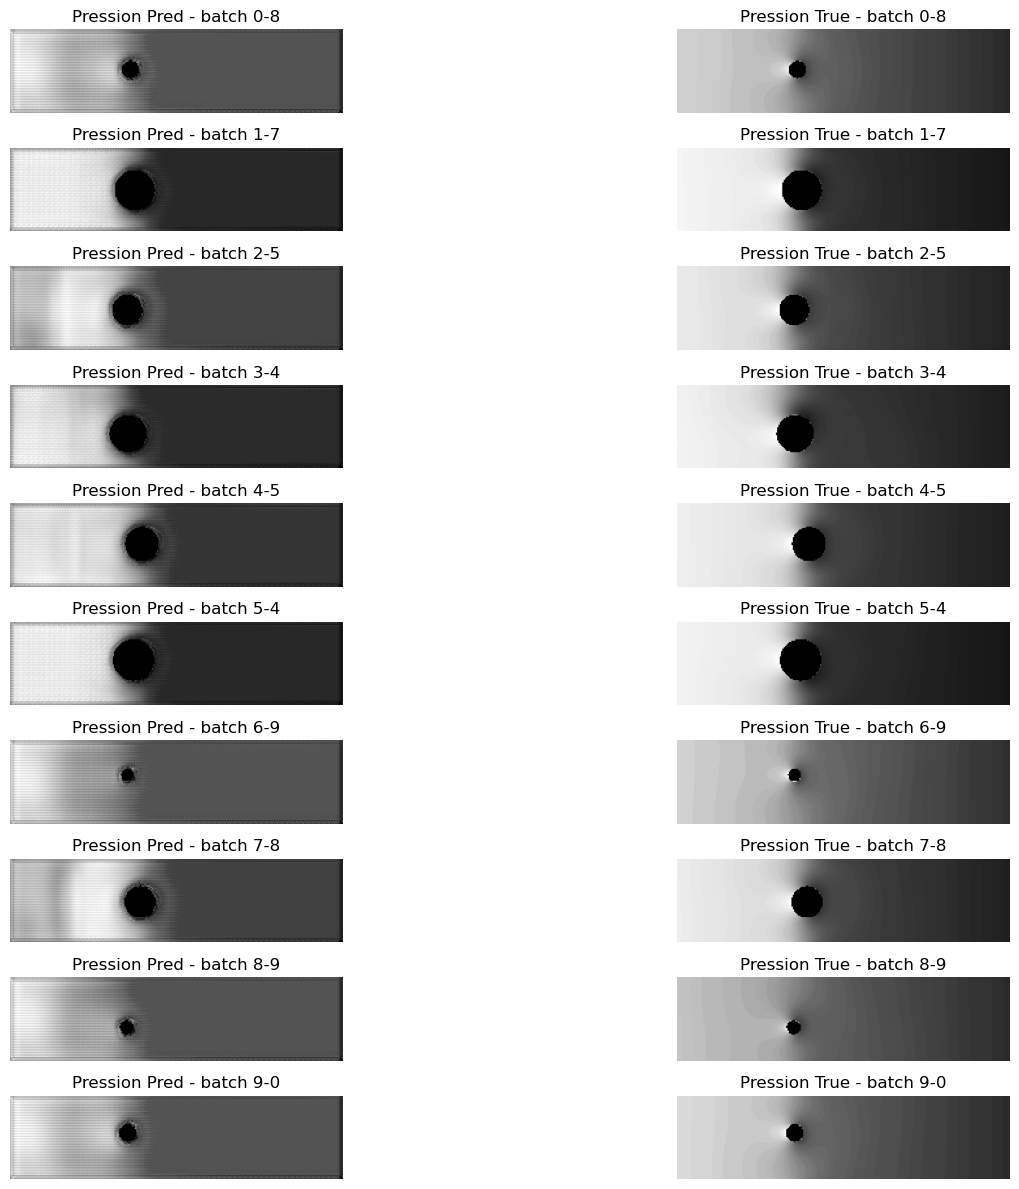

In [36]:
fig, axes = plt.subplots(10, 2, figsize=(16, 12))

for i in range(nbatch):
    N = random.randint(0, nbatch-1)
    titles = [ 'P pred', 'P true']
    axes[i, 0].imshow(ypred[i][N], cmap='gray'); axes[i, 0].set_title(f'Pression Pred - batch {i}-{N}')
    axes[i, 1].imshow(ytrue[i][N], cmap='gray'); axes[i, 1].set_title(f'Pression True - batch {i}-{N}')

for ax in axes.flat:
    ax.axis('off')    

plt.tight_layout()
plt.show()     

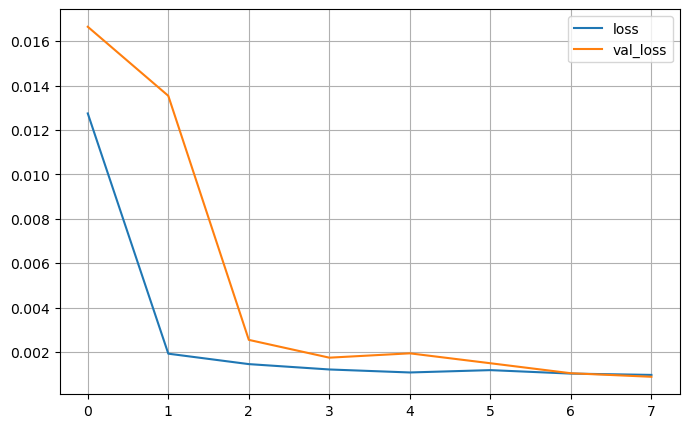

In [37]:
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(8, 5))
plt.grid(True)
plt.show()
fig.savefig("Test_1_Adam_Loss.png", dpi=300, bbox_inches='tight')

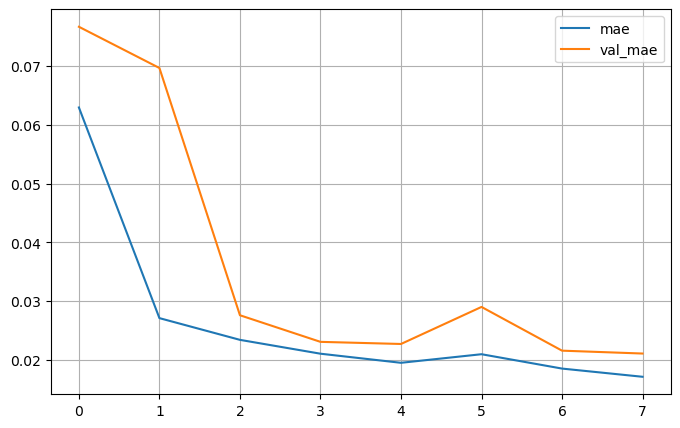

In [38]:
pd.DataFrame(history.history)[['mae', 'val_mae']].plot(figsize=(8, 5))
plt.grid(True)
plt.show()  
fig.savefig("Test_1_Adam_Mae.png", dpi=300, bbox_inches='tight')    